In [55]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/online_retail_II.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Libraries loaded ✅")

Libraries loaded ✅


In [58]:
df = pd.read_csv("/content/drive/MyDrive/online_retail_II.csv", encoding="latin1")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())
df.head()

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [59]:
print("Null values:")
print(df.isnull().sum())

Null values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [60]:
df = df[df["Country"] == "United Kingdom"]
print("UK only rows:", df.shape[0])

UK only rows: 981330


In [61]:
df = df.dropna(subset=["Customer ID"])
df = df.drop_duplicates()
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Customer ID"] = df["Customer ID"].astype(int)
df["Description"] = df["Description"].fillna("Unknown Item")
df["Total_Revenue"] = df["Quantity"] * df["Price"]

print("Cleaned shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned shape: (700388, 9)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Total_Revenue']


In [62]:
print(df.describe())

            Quantity                    InvoiceDate          Price  \
count  700388.000000                         700388  700388.000000   
mean       12.182406  2010-12-31 23:44:07.008658176       3.065463   
min         1.000000            2009-12-01 07:45:00       0.001000   
25%         2.000000            2010-06-30 13:41:00       1.250000   
50%         4.000000            2010-11-30 12:43:00       1.950000   
75%        12.000000            2011-07-31 11:26:00       3.750000   
max     80995.000000            2011-12-09 12:49:00   10953.500000   
std       143.109933                            NaN      25.598485   

         Customer ID  Total_Revenue  
count  700388.000000  700388.000000  
mean    15550.404903      20.544662  
min     12346.000000       0.001000  
25%     14194.000000       4.250000  
50%     15547.000000      10.500000  
75%     16933.000000      17.850000  
max     18287.000000  168469.600000  
std      1592.453861     237.748856  


In [ ]:
daily_sales_df = df.groupby(df["InvoiceDate"].dt.date)["Total_Revenue"].sum().reset_index()
daily_sales_df.columns = ["ds", "y"]
daily_sales_df["ds"] = pd.to_datetime(daily_sales_df["ds"])
daily_sales_df = daily_sales_df.sort_values("ds").reset_index(drop=True)

print("Daily rows:", len(daily_sales_df))        # 604 aana chahiye
print("Max revenue:", daily_sales_df["y"].max()) # 184347 aana chahiye
print("Zero days:", (daily_sales_df["y"] == 0).sum()) # 0 aana chahiye


Daily rows: 604
Max revenue: 179543.16
Zero days: 0


In [64]:
# Saturday manually zero karo — resample nahi, sirf Saturday fix
daily_sales_df["is_saturday"] = daily_sales_df["ds"].dt.dayofweek == 5
print("Saturdays in data:", daily_sales_df["is_saturday"].sum())

Saturdays in data: 1


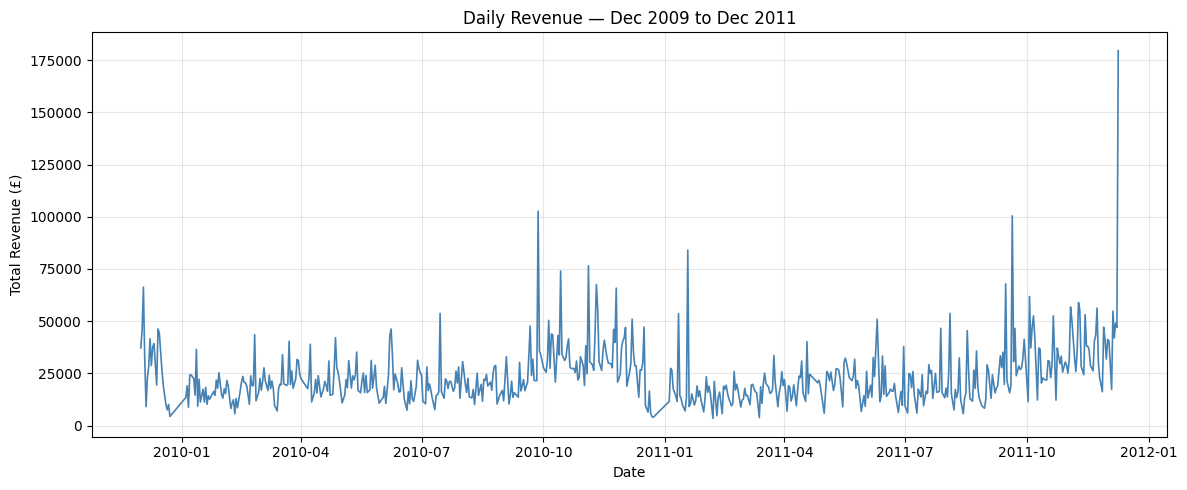

In [65]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales_df["ds"], daily_sales_df["y"], color="steelblue", linewidth=1.2)
plt.title("Daily Revenue — Dec 2009 to Dec 2011")
plt.xlabel("Date")
plt.ylabel("Total Revenue (£)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

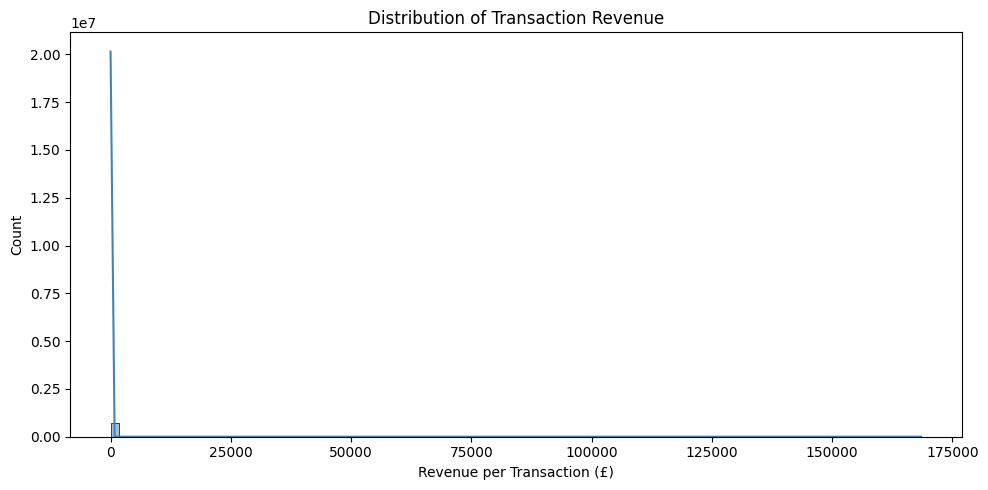

In [66]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Total_Revenue"], bins=100, color="steelblue", kde=True)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue per Transaction (£)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

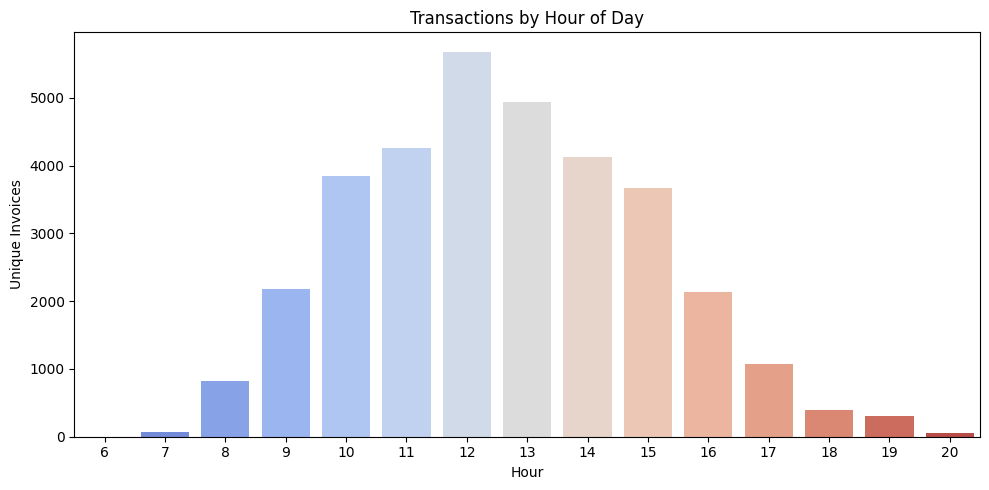

In [67]:
df["Hour"] = df["InvoiceDate"].dt.hour
hourly = df.groupby("Hour")["Invoice"].nunique()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly.index, y=hourly.values, palette="coolwarm")
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Unique Invoices")
plt.tight_layout()
plt.show()

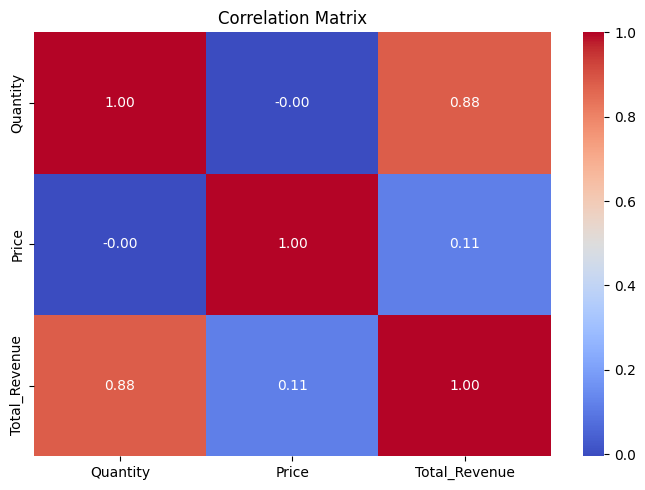

In [68]:
num_cols = df[["Quantity", "Price", "Total_Revenue"]].copy()
plt.figure(figsize=(7, 5))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

RFM

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Total_Revenue", "sum")
).reset_index()

print("RFM shape:", rfm.shape)  # 5878 customers
print(rfm.describe())
rfm.head()

RFM shape: (5350, 4)
        Customer ID      Recency    Frequency       Monetary
count   5350.000000  5350.000000  5350.000000    5350.000000
mean   15557.362617   203.000935     6.269346    2689.576620
std     1581.161762   209.959231    11.995550   11706.527439
min    12346.000000     1.000000     1.000000       2.950000
25%    14191.250000    26.000000     1.000000     330.202500
50%    15565.500000    98.500000     3.000000     829.440000
75%    16922.750000   382.000000     7.000000    2156.250000
max    18287.000000   739.000000   336.000000  580987.040000


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12608,405,1,415.79
2,12745,487,2,723.85
3,12746,541,1,254.55
4,12747,2,26,8898.48


In [70]:
!pip install pandera -q

In [71]:
import pandera.pandas as pa

rfm_schema = pa.DataFrameSchema({
    "Customer ID": pa.Column(int, nullable=False),
    "Recency": pa.Column(int, pa.Check.between(0, 750)),
    "Frequency": pa.Column(int, pa.Check.greater_than_or_equal_to(1)),
    "Monetary": pa.Column(float, pa.Check.greater_than(0))
})

try:
    rfm_schema.validate(rfm, lazy=True)
    print("RFM Validation: PASSED ✅")
except pa.errors.SchemaErrors as err:
    print("Validation FAILED")
    display(err.failure_cases[["column", "check", "failure_case", "index"]])

RFM Validation: PASSED ✅


In [72]:
daily_platform_revenue = daily_sales_df.copy()
daily_platform_revenue = daily_platform_revenue.set_index("ds")

daily_platform_revenue["Rolling_mean_7D"]  = daily_platform_revenue["y"].rolling(window=7,  min_periods=1).mean()
daily_platform_revenue["Rolling_mean_30D"] = daily_platform_revenue["y"].rolling(window=30, min_periods=1).mean()
daily_platform_revenue["Rolling_std_30D"]  = daily_platform_revenue["y"].rolling(window=30, min_periods=1).std().fillna(0)

print(daily_platform_revenue.tail())

                    y  is_saturday  Rolling_mean_7D  Rolling_mean_30D  \
ds                                                                      
2011-12-05   54792.12        False     39150.132857      37634.041667   
2011-12-06   41915.02        False     38407.112857      38196.285667   
2011-12-07   49129.86        False     39518.714286      38782.189333   
2011-12-08   47023.92        False     41691.237143      38456.247667   
2011-12-09  179543.16        False     61452.951429      42754.951000   

            Rolling_std_30D  
ds                           
2011-12-05     12270.096305  
2011-12-06     12058.091955  
2011-12-07     12150.830615  
2011-12-08     11776.155243  
2011-12-09     28299.977539  


In [73]:
daily_sales_df.shape

(604, 3)

In [74]:
rfm.shape

(5350, 4)

In [75]:
from sklearn.preprocessing import StandardScaler

rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])

print("Scaled shape:", rfm_scaled.shape)
print(rfm_scaled.describe().round(2))

Scaled shape: (5350, 3)
       Recency  Frequency  Monetary
count  5350.00    5350.00   5350.00
mean     -0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -2.41      -1.06     -3.93
25%      -0.75      -1.06     -0.71
50%       0.09      -0.21     -0.04
75%       0.95       0.65      0.66
max       1.37       5.26      4.73


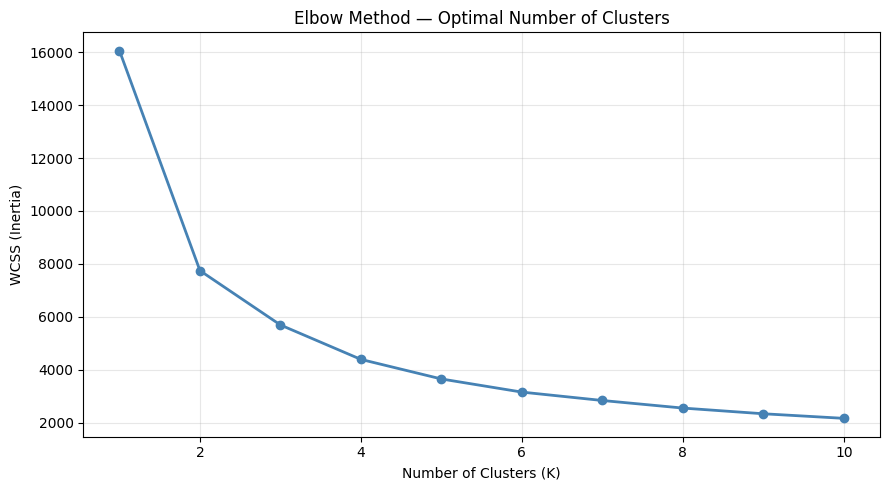

In [76]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
!pip install kneed -q
from kneed import KneeLocator

knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print(f"Optimal K: {optimal_k}")

Optimal K: 3


In [78]:
kmeans = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10)
kmeans_labels = kmeans.fit_predict(rfm_scaled)

rfm["KMeans_Cluster"] = kmeans_labels

print("Cluster distribution:")
print(rfm["KMeans_Cluster"].value_counts().sort_index())

Cluster distribution:
KMeans_Cluster
0    2063
1    2183
2    1104
Name: count, dtype: int64


In [79]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(rfm_scaled, kmeans_labels, random_state=SEED)
print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")

KMeans Silhouette Score: 0.3518


In [80]:
cluster_profiles = rfm.groupby("KMeans_Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Customer_Count=("Customer ID", "count")
).round(2)

print(cluster_profiles)

                Recency  Frequency  Monetary  Customer_Count
KMeans_Cluster                                              
0                113.02       4.43   1457.01            2063
1                374.33       1.53    367.80            2183
2                 32.35      19.07   9583.81            1104


In [81]:
cluster_names = {}
profiles = rfm.groupby("KMeans_Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
)

# Best cluster = low recency + high monetary = Champions
best_cluster  = profiles["Monetary"].idxmax()
worst_cluster = profiles["Recency"].idxmax()
mid_cluster   = [c for c in range(optimal_k)
                 if c != best_cluster and c != worst_cluster][0]

cluster_names[best_cluster]  = "Champions"
cluster_names[mid_cluster]   = "Loyal Customers"
cluster_names[worst_cluster] = "At-Risk / Lost"

rfm["Segment"] = rfm["KMeans_Cluster"].map(cluster_names)
print(rfm["Segment"].value_counts())

Segment
At-Risk / Lost     2183
Loyal Customers    2063
Champions          1104
Name: count, dtype: int64


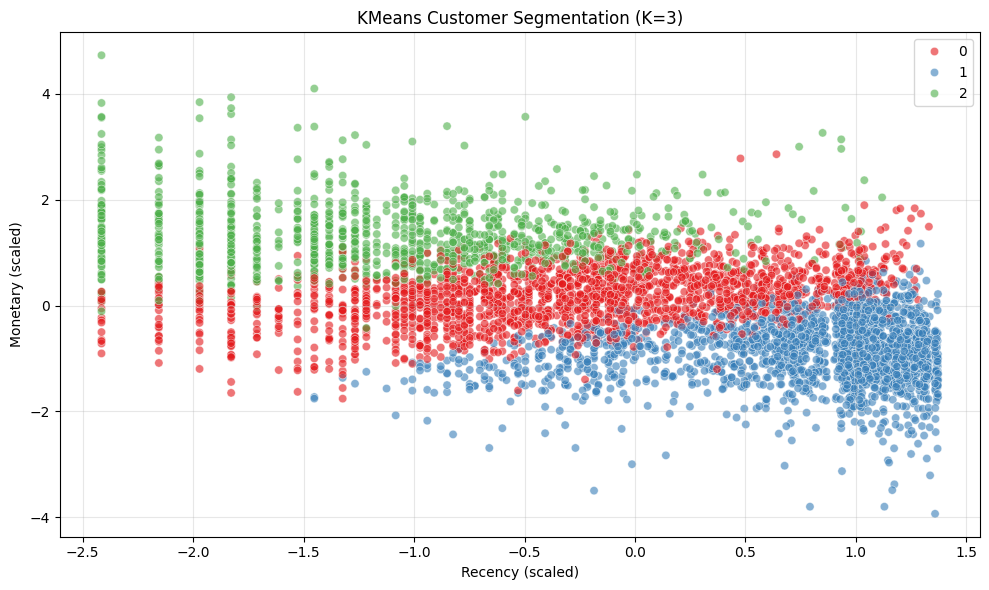

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=rfm_scaled["Recency"],
    y=rfm_scaled["Monetary"],
    hue=kmeans_labels,
    palette="Set1",
    alpha=0.6
)
plt.title(f"KMeans Customer Segmentation (K={optimal_k})")
plt.xlabel("Recency (scaled)")
plt.ylabel("Monetary (scaled)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

DBSCAN

In [83]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"DBSCAN Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")
print("Label distribution:", pd.Series(dbscan_labels).value_counts().sort_index().to_dict())

DBSCAN Clusters found: 2
Noise points: 57
Label distribution: {-1: 57, 0: 1469, 1: 3824}


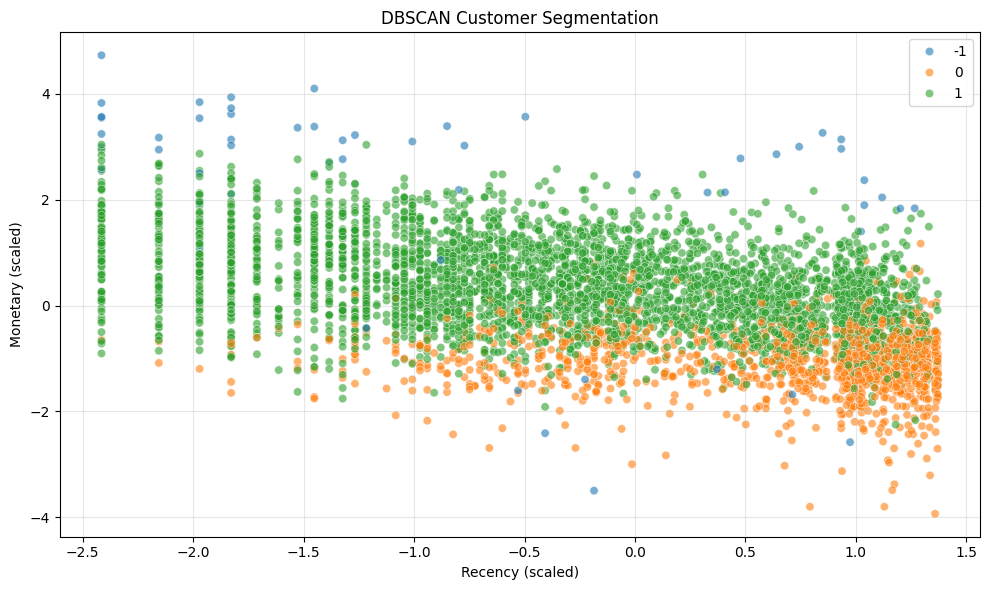

In [84]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=rfm_scaled["Recency"],
    y=rfm_scaled["Monetary"],
    hue=dbscan_labels,
    palette="tab10",
    alpha=0.6
)
plt.title("DBSCAN Customer Segmentation")
plt.xlabel("Recency (scaled)")
plt.ylabel("Monetary (scaled)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
print("=" * 45)
print("   CLUSTERING COMPARISON")
print("=" * 45)
print(f"  KMeans  → Clusters: {optimal_k},  Silhouette: {kmeans_silhouette:.4f}")
print(f"  DBSCAN  → Clusters: {n_clusters},  Noise pts: {n_noise}")
print("=" * 45)
print("\nKMeans Cluster Profiles:")
print(cluster_profiles)

   CLUSTERING COMPARISON
  KMeans  → Clusters: 3,  Silhouette: 0.3518
  DBSCAN  → Clusters: 2,  Noise pts: 57

KMeans Cluster Profiles:
                Recency  Frequency  Monetary  Customer_Count
KMeans_Cluster                                              
0                113.02       4.43   1457.01            2063
1                374.33       1.53    367.80            2183
2                 32.35      19.07   9583.81            1104


Time Series Preparation + Stationarity Test

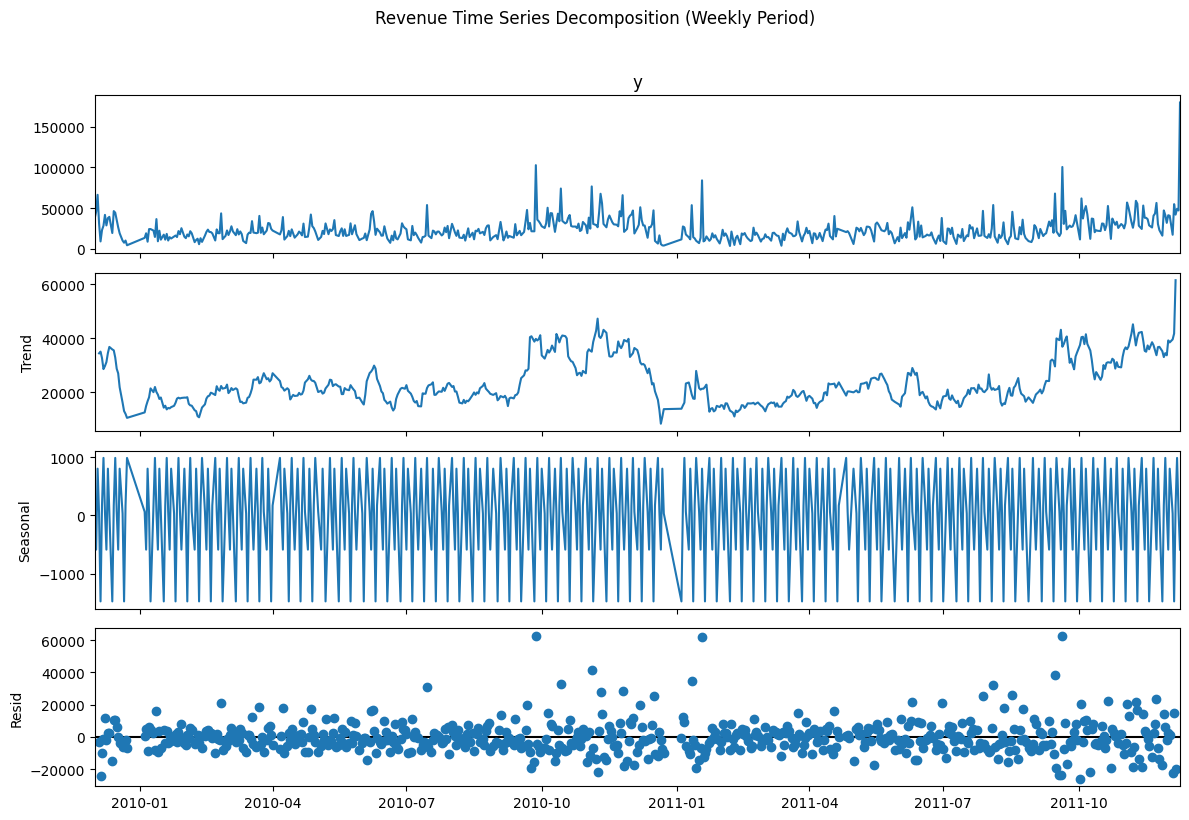

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

ts = daily_sales_df.set_index("ds")["y"]

decomposition = seasonal_decompose(ts, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Revenue Time Series Decomposition (Weekly Period)", y=1.02)
plt.tight_layout()
plt.show()

In [87]:
result = adfuller(daily_sales_df["y"])

print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print()
if result[1] < 0.05:
    print("Data is STATIONARY (p < 0.05)")
else:
    print("Data is NON-STATIONARY (p > 0.05)")

ADF Statistic : -2.4781
p-value       : 0.1209

Data is NON-STATIONARY (p > 0.05)


In [88]:
n_test = 30

prophet_df = daily_sales_df.copy()
prophet_df["is_weekend"] = prophet_df["ds"].dt.dayofweek.isin([5, 6]).astype(int)

train_df = prophet_df.iloc[:-n_test].reset_index(drop=True)
test_df  = prophet_df.iloc[-n_test:].reset_index(drop=True)

cap_value = train_df["y"].quantile(0.99)
train_df["y"] = train_df["y"].clip(upper=cap_value)


print("Train size:", len(train_df))
print("Test period:", test_df["ds"].min().date(), "to", test_df["ds"].max().date())
print("Train mean:", train_df["y"].mean().round(2))
print("Test mean:", test_df["y"].mean().round(2))

Train size: 574
Test period: 2011-11-06 to 2011-12-09
Train mean: 22659.97
Test mean: 42754.95


In [89]:
print(test_df[["ds","y"]].to_string())

           ds          y
0  2011-11-06   32722.98
1  2011-11-07   25804.79
2  2011-11-08   35682.88
3  2011-11-09   58897.32
4  2011-11-10   55279.60
5  2011-11-11   28352.95
6  2011-11-13   24352.15
7  2011-11-14   53081.37
8  2011-11-15   38101.21
9  2011-11-16   37992.44
10 2011-11-17   36321.25
11 2011-11-18   28741.15
12 2011-11-20   26148.84
13 2011-11-21   40569.48
14 2011-11-22   43255.59
15 2011-11-23   56292.41
16 2011-11-24   30403.66
17 2011-11-25   22846.23
18 2011-11-27   16139.34
19 2011-11-28   47116.16
20 2011-11-29   41348.65
21 2011-11-30   31816.26
22 2011-12-01   41211.16
23 2011-12-02   40519.88
24 2011-12-04   17246.70
25 2011-12-05   54792.12
26 2011-12-06   41915.02
27 2011-12-07   49129.86
28 2011-12-08   47023.92
29 2011-12-09  179543.16


 Prophet Baseline Model

In [90]:
!pip install prophet -q

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [91]:
prophet_model = Prophet(
    growth = "linear",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=1
)
prophet_model.add_country_holidays(country_name="GB")
prophet_model.add_regressor("is_weekend")

prophet_model.fit(train_df)
print("Prophet model trained ✅")

Prophet model trained ✅


In [92]:
last_train_date = train_df["ds"].max()
last_test_date  = test_df["ds"].max()
days_gap = (last_test_date - last_train_date).days

future = prophet_model.make_future_dataframe(periods=days_gap, freq="D")
future["is_weekend"] = future["ds"].dt.dayofweek.isin([5, 6]).astype(int)
prophet_forecast = prophet_model.predict(future)

prophet_predictions = prophet_forecast[
    prophet_forecast["ds"].isin(test_df["ds"])
][["ds", "yhat"]].reset_index(drop=True)

print("Shape:", prophet_predictions.shape)  # (30, 2)

Shape: (30, 2)


In [93]:
# test_df ke saath merge karo date pe
evaluation_df = test_df.merge(prophet_predictions, on="ds")

# Negative predictions zero karo — revenue negative nahi hoti
evaluation_df["yhat"] = evaluation_df["yhat"].clip(lower=0)

normal_days = evaluation_df[evaluation_df["y"] < 100000]
spike_days  = evaluation_df[evaluation_df["y"] >= 100000]

print(evaluation_df[["ds", "y", "yhat"]].to_string())

           ds          y          yhat
0  2011-11-06   32722.98  26601.457563
1  2011-11-07   25804.79  37181.913006
2  2011-11-08   35682.88  41610.275441
3  2011-11-09   58897.32  37474.171260
4  2011-11-10   55279.60  47199.417663
5  2011-11-11   28352.95  34401.598595
6  2011-11-13   24352.15  28114.292102
7  2011-11-14   53081.37  38625.615503
8  2011-11-15   38101.21  42905.071068
9  2011-11-16   37992.44  38500.226998
10 2011-11-17   36321.25  48266.410489
11 2011-11-18   28741.15  35128.684796
12 2011-11-20   26148.84  28657.290310
13 2011-11-21   40569.48  39386.487410
14 2011-11-22   43255.59  43790.718771
15 2011-11-23   56292.41  39362.534968
16 2011-11-24   30403.66  49372.793608
17 2011-11-25   22846.23  36043.542709
18 2011-11-27   16139.34  29480.719061
19 2011-11-28   47116.16  40358.366823
20 2011-11-29   41348.65  44736.379136
21 2011-11-30   31816.26  40052.819772
22 2011-12-01   41211.16  49997.768439
23 2011-12-02   40519.88  36097.071273
24 2011-12-04   17246.70 

In [94]:
prophet_mae  = mean_absolute_error(evaluation_df["y"], evaluation_df["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(evaluation_df["y"], evaluation_df["yhat"]))

# MAPE — zero revenue days ko mask karo (division by zero avoid karne ke liye)
mask = evaluation_df["y"] != 0
prophet_mape = np.mean(
    np.abs((evaluation_df["y"][mask] - evaluation_df["yhat"][mask]) / evaluation_df["y"][mask])
) * 100

prophet_mae_normal = mean_absolute_error(normal_days["y"], normal_days["yhat"])
prophet_mape_normal = np.mean(
    np.abs((normal_days["y"] - normal_days["yhat"]) / normal_days["y"])
) * 100

print("=" * 45)
print("   PROPHET MODEL PERFORMANCE")
print("=" * 45)
print(f"  MAE  : {prophet_mae:,.2f}")
print(f"  RMSE : {prophet_rmse:,.2f}")
print(f"  MAPE : {prophet_mape:.2f}%")
print(f"  Normal Days MAE  : {prophet_mae_normal:,.2f}  (29 days, exc. Dec 9)")
print(f"  Normal Days MAPE : {prophet_mape_normal:.2f}%")
print("=" * 45)

   PROPHET MODEL PERFORMANCE
  MAE  : 12,896.68
  RMSE : 28,735.66
  MAPE : 26.47%
  Normal Days MAE  : 8,245.91  (29 days, exc. Dec 9)
  Normal Days MAPE : 24.54%


In [ ]:
train_pred = prophet_model.predict(train_df[["ds", "is_weekend"]])
train_mae = mean_absolute_error(train_df["y"], train_pred["yhat"])
print("Train MAE:", round(train_mae, 2))
print("Test MAE:", round(prophet_mae, 2))
print("Ratio (Test/Train):", round(prophet_mae/train_mae, 2))
# Agar ratio > 3 toh overfit hai

Train MAE: 5991.35
Test MAE: 12896.68
Ratio (Test/Train): 2.15


In [96]:
print("UK filter applied:", df["Country"].unique())
print("Total rows after UK filter:", df.shape[0])
print("daily_sales_df rows:", len(daily_sales_df))
print("Max revenue:", daily_sales_df["y"].max())
print("Train mean:", train_df["y"].mean().round(2))
print("Test mean:", test_df["y"].mean().round(2))
print("is_weekend in train_df:", "is_weekend" in train_df.columns)

UK filter applied: ['United Kingdom']
Total rows after UK filter: 700388
daily_sales_df rows: 604
Max revenue: 179543.16
Train mean: 22659.97
Test mean: 42754.95
is_weekend in train_df: True


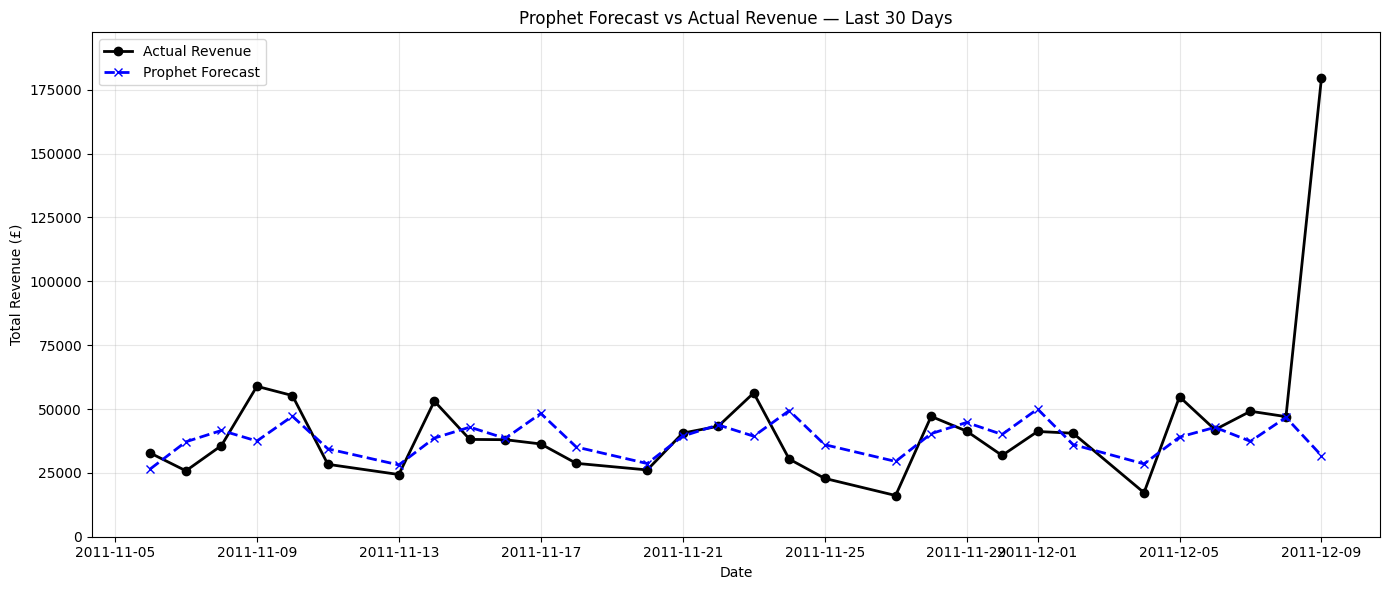

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(evaluation_df["ds"], evaluation_df["y"],
         label="Actual Revenue", marker="o", color="black", linewidth=2)
plt.plot(evaluation_df["ds"], evaluation_df["yhat"],
         label="Prophet Forecast", marker="x", color="blue",
         linestyle="--", linewidth=2)

plt.ylim(0, evaluation_df["y"].max() * 1.1)

plt.title("Prophet Forecast vs Actual Revenue — Last 30 Days")
plt.xlabel("Date")
plt.ylabel("Total Revenue (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LSTM Model

In [98]:
!pip install pytorch-lightning -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
pl.seed_everything(SEED, workers=True)

print("PyTorch version:", torch.__version__)

INFO:lightning_fabric.utilities.seed:Seed set to 42


PyTorch version: 2.11.0+cpu


In [ ]:
n_test = 30

train_raw = daily_sales_df["y"].values[:-n_test].reshape(-1, 1)  # (574, 1)
test_raw  = daily_sales_df["y"].values[-n_test:].reshape(-1, 1)  # (30, 1)

scaler_lstm = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler_lstm.fit_transform(train_raw)
test_scaled  = scaler_lstm.transform(test_raw)
scaled_revenue = scaler_lstm.fit_transform(
    daily_sales_df["y"].values.reshape(-1, 1)
)

print("train_scaled shape:", train_scaled.shape)
print("test_scaled shape :", test_scaled.shape)
print("scaled_revenue shape :", scaled_revenue.shape)

train_scaled shape: (574, 1)
test_scaled shape : (30, 1)
scaled_revenue shape : (604, 1)


In [ ]:
sequence_length = 14

def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

x, y_seq = create_sequences(scaled_revenue, sequence_length)

x_train = x[:-n_test]
x_test  = x[-n_test:]
y_train = y_seq[:-n_test]
y_test  = y_seq[-n_test:]

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

x_train: (560, 14, 1)
x_test : (30, 14, 1)


In [101]:
train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(x_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1,  shuffle=False)

print("Train batches:", len(train_loader))

Train batches: 35


In [102]:
class LSTMForecaster(pl.LightningModule):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,dropout=0.2)
        self.linear  = nn.Linear(hidden_size, 1)
        self.loss_fn = nn.HuberLoss(delta=1.0)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:, -1, :])

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [103]:
lstm_model = LSTMForecaster()
pl.seed_everything(SEED, workers=True)

trainer = pl.Trainer(
    max_epochs=300,
    accelerator="auto",
    enable_checkpointing=False,
    logger=False,
    deterministic=True
)

trainer.fit(lstm_model, train_loader)
print("LSTM Training complete")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM      │  199 K │ train │     0 │
│ 1 │ linear  │ Linear    │    129 │ train │     0 │
│ 2 │ loss_fn │ HuberLoss │      0 │ train │     0 │
└───┴─────────┴───────────┴────────┴───────┴───────┘

Trainable params: 199 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 199 K                                                                                                
Total estimated model params size (MB): 0.797                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.


LSTM Training complete


In [ ]:
lstm_model.eval()

with torch.no_grad():
    preds_scaled = lstm_model(torch.tensor(x_test, dtype=torch.float32))
    lstm_preds = scaler_lstm.inverse_transform(preds_scaled.numpy())
    
lstm_preds = np.maximum(lstm_preds, 0).flatten()

print("LSTM predictions shape:", lstm_preds.shape)
print("Sample predictions:", lstm_preds[:5].round(2))

LSTM predictions shape: (30,)
Sample predictions: [46504.58 37527.44 42246.56 53267.54 53531.17]


In [105]:
actual_sales = test_df["y"].values

lstm_mae  = mean_absolute_error(actual_sales, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(actual_sales, lstm_preds))

mask = actual_sales != 0
lstm_mape = np.mean(
    np.abs((actual_sales[mask] - lstm_preds[mask]) / actual_sales[mask])
) * 100

print("=" * 45)
print("   LSTM MODEL PERFORMANCE")
print("=" * 45)
print(f"  MAE  : {lstm_mae:,.2f}")
print(f"  RMSE : {lstm_rmse:,.2f}")
print(f"  MAPE : {lstm_mape:.2f}%")
print("=" * 45)

   LSTM MODEL PERFORMANCE
  MAE  : 14,771.68
  RMSE : 31,451.45
  MAPE : 30.32%


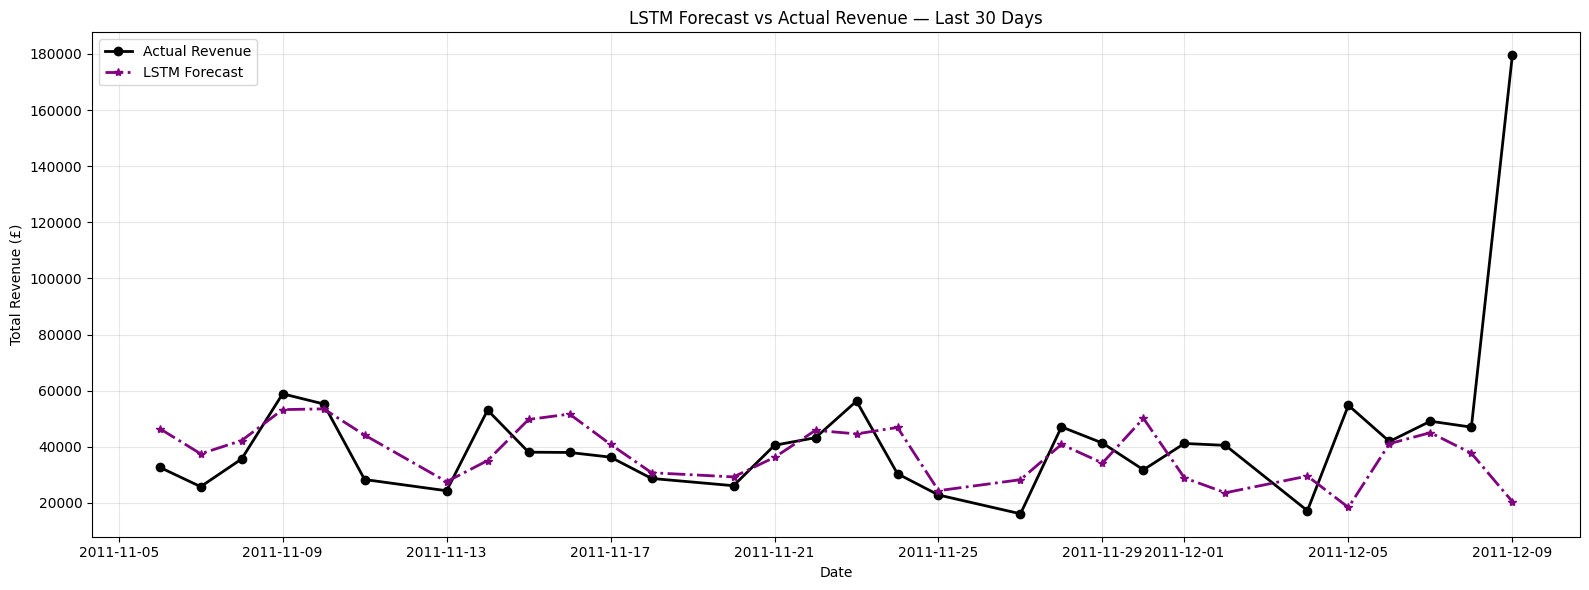

In [106]:
plt.figure(figsize=(16, 6))
plt.plot(test_df["ds"].values, actual_sales,
         label="Actual Revenue", marker="o", color="black", linewidth=2)
plt.plot(test_df["ds"].values, lstm_preds,
         label="LSTM Forecast", marker="*", color="purple",
         linestyle="-.", linewidth=2)
# plt.ylim(0, max(actual_sales.max(), lstm_preds.max()) * 1.1)
plt.title("LSTM Forecast vs Actual Revenue — Last 30 Days")
plt.xlabel("Date")
plt.ylabel("Total Revenue (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [107]:
print("daily_sales_df rows:", len(daily_sales_df))
print("scaled_revenue shape:", scaled_revenue.shape)
print("x shape:", x.shape)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("train_loader batches:", len(train_loader))

daily_sales_df rows: 604
scaled_revenue shape: (604, 1)
x shape: (590, 14, 1)
x_train shape: (560, 14, 1)
x_test shape: (30, 14, 1)
train_loader batches: 35


 Hybrid Ensemble Model

In [ ]:
prophet_preds = evaluation_df["yhat"].values  
lstm_preds_hybrid = lstm_preds 

actual_sales = test_df["y"].values  # (30,)

w_prophet = 0.70
w_lstm    = 0.30

hybrid_preds = (w_prophet * prophet_preds) + (w_lstm * lstm_preds_hybrid)
hybrid_preds = np.maximum(hybrid_preds, 0)

print("Hybrid predictions ready")
print("Sample:", hybrid_preds[:5].round(2))

Hybrid predictions ready
Sample: [32572.39 37285.57 41801.16 42212.18 49098.94]


In [109]:
hybrid_mae  = mean_absolute_error(actual_sales, hybrid_preds)
hybrid_rmse = np.sqrt(mean_squared_error(actual_sales, hybrid_preds))

mask = actual_sales != 0
hybrid_mape = np.mean(
    np.abs((actual_sales[mask] - hybrid_preds[mask]) / actual_sales[mask])
) * 100

print("=" * 50)
print("      FINAL MODEL COMPARISON")
print("=" * 50)
print(f"  Prophet  → MAE: {prophet_mae:>10,.2f}  RMSE: {prophet_rmse:>10,.2f}  MAPE: {prophet_mape:.2f}%")
print(f"  LSTM     → MAE: {lstm_mae:>10,.2f}  RMSE: {lstm_rmse:>10,.2f}  MAPE: {lstm_mape:.2f}%")
print(f"  Hybrid   → MAE: {hybrid_mae:>10,.2f}  RMSE: {hybrid_rmse:>10,.2f}  MAPE: {hybrid_mape:.2f}%")
print("=" * 50)
print("  (Lower = Better)")

      FINAL MODEL COMPARISON
  Prophet  → MAE:  12,896.68  RMSE:  28,735.66  MAPE: 26.47%
  LSTM     → MAE:  14,771.68  RMSE:  31,451.45  MAPE: 30.32%
  Hybrid   → MAE:  12,780.10  RMSE:  29,245.55  MAPE: 25.80%
  (Lower = Better)


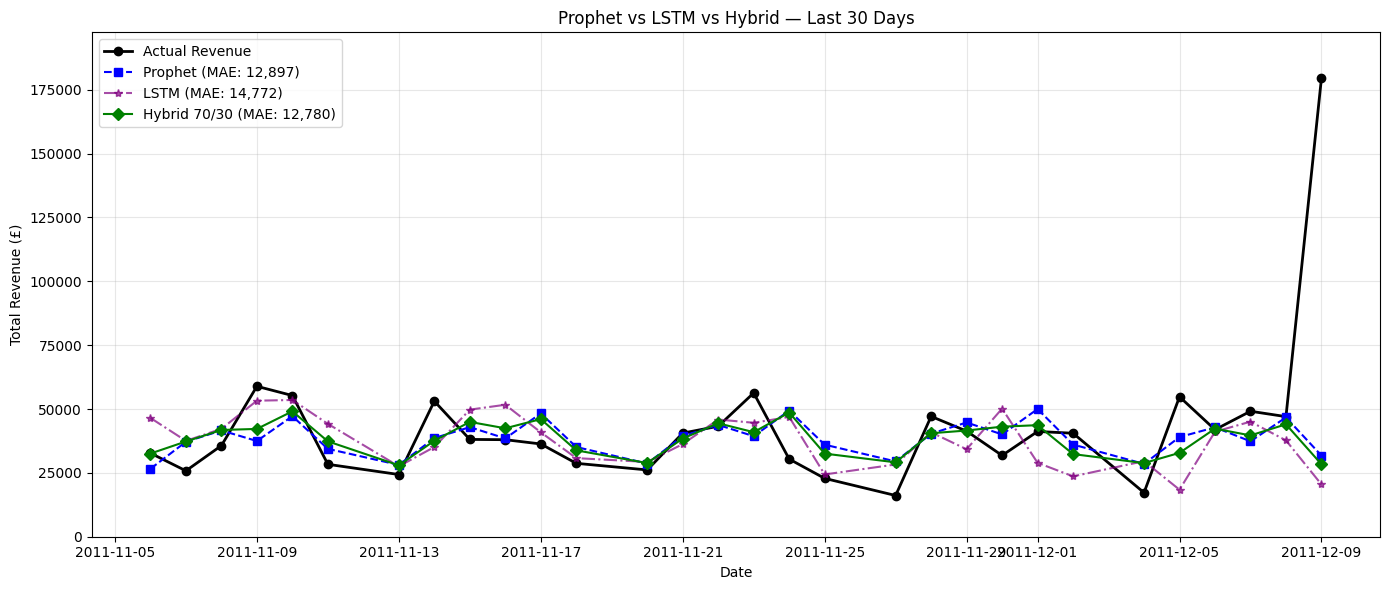

In [110]:
plt.figure(figsize=(14, 6))

plt.plot(test_df["ds"].values, actual_sales,
         label="Actual Revenue", marker="o", color="black", linewidth=2)

plt.plot(test_df["ds"].values, prophet_preds,
         label=f"Prophet (MAE: {prophet_mae:,.0f})", marker="s",
         color="blue", linestyle="--", linewidth=1.5)

plt.plot(test_df["ds"].values, lstm_preds_hybrid,
         label=f"LSTM (MAE: {lstm_mae:,.0f})", marker="*",
         color="purple", linestyle="-.", linewidth=1.5, alpha=0.7)

plt.plot(test_df["ds"].values, hybrid_preds,
         label=f"Hybrid 70/30 (MAE: {hybrid_mae:,.0f})", marker="D",
         color="green", linewidth=1.5)

plt.ylim(0, max(actual_sales.max(), hybrid_preds.max()) * 1.1)
plt.title("Prophet vs LSTM vs Hybrid — Last 30 Days")
plt.xlabel("Date")
plt.ylabel("Total Revenue (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [111]:
comparison_df = pd.DataFrame({
    "Date"             : test_df["ds"].dt.strftime("%Y-%m-%d"),
    "Actual"           : actual_sales.round(2),
    "Prophet_Pred"     : prophet_preds.round(2),
    "LSTM_Pred"        : lstm_preds_hybrid.round(2),
    "Hybrid_Pred"      : hybrid_preds.round(2),
    "Hybrid_Error"     : np.abs(actual_sales - hybrid_preds).round(2)
})

print(comparison_df.to_string(index=False))

      Date    Actual  Prophet_Pred    LSTM_Pred  Hybrid_Pred  Hybrid_Error
2011-11-06  32722.98      26601.46 46504.578125     32572.39        150.59
2011-11-07  25804.79      37181.91 37527.441406     37285.57      11480.78
2011-11-08  35682.88      41610.28 42246.558594     41801.16       6118.28
2011-11-09  58897.32      37474.17 53267.539062     42212.18      16685.14
2011-11-10  55279.60      47199.42 53531.171875     49098.94       6180.66
2011-11-11  28352.95      34401.60 44191.371094     37338.53       8985.58
2011-11-13  24352.15      28114.29 27565.669922     27949.71       3597.56
2011-11-14  53081.37      38625.62 35115.179688     37572.48      15508.89
2011-11-15  38101.21      42905.07 49757.949219     44960.94       6859.73
2011-11-16  37992.44      38500.23 51671.621094     42451.64       4459.20
2011-11-17  36321.25      48266.41 40877.710938     46049.80       9728.55
2011-11-18  28741.15      35128.68 30777.349609     33823.28       5082.13
2011-11-20  26148.84     

Churn Prediction (XGBoost + SHAP)

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

churn_df = df.groupby("Customer ID").agg(
    Frequency     = ("Invoice", "nunique"),
    Monetary      = ("Total_Revenue", "sum"),
    Tenure        = ("InvoiceDate", lambda x: (x.max() - x.min()).days),
    AvgOrderValue = ("Total_Revenue", "mean"),
    TotalItems    = ("Quantity", "sum"),
    AvgQuantity   = ("Quantity", "mean"),
    UniqueProducts= ("StockCode", "nunique"),
    LastRevenue   = ("Total_Revenue", "last"),
    StdRevenue    = ("Total_Revenue", "std"),
    PurchaseSpan  = ("InvoiceDate", lambda x: (x.max() - x.min()).days + 1),
    Recency       = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    MaxRevenue     = ("Total_Revenue", "max"),
    MonthsActive   = ("InvoiceDate", lambda x: x.dt.to_period("M").nunique())
).reset_index()

churn_df["StdRevenue"] = churn_df["StdRevenue"].fillna(0)
churn_df["AvgDaysBetweenPurchases"] = (
    churn_df["PurchaseSpan"] / churn_df["Frequency"].clip(lower=1)
)
churn_df["RevenuePerItem"] = (
    churn_df["Monetary"] / churn_df["TotalItems"].clip(lower=1)
)
churn_df["RevenueConsistency"] = (
    churn_df["StdRevenue"] / churn_df["AvgOrderValue"].clip(lower=1)
)

churn_df["Churned"] = (churn_df["Recency"] > 90).astype(int)

print("Total customers:", len(churn_df))
print("Churned:", churn_df["Churned"].sum())
print("Active:", (churn_df["Churned"] == 0).sum())
print("Churn rate:", f"{churn_df['Churned'].mean()*100:.1f}%")

Total customers: 5350
Churned: 2737
Active: 2613
Churn rate: 51.2%


In [113]:
# XGBoost Model

In [114]:
from sklearn.model_selection import train_test_split

features = [
  "Frequency", "Monetary", "Tenure", "AvgOrderValue",
    "TotalItems", "AvgQuantity", "UniqueProducts",
    "LastRevenue", "StdRevenue", "AvgDaysBetweenPurchases",
    "RevenuePerItem", "MaxRevenue", "MonthsActive",
    "RevenueConsistency","PurchaseSpan"
]
target = "Churned"

X = churn_df[features]
y = churn_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Features:", len(features))
print("Churn ratio train:", y_train.mean().round(3))

X_train: (4280, 15)
X_test: (1070, 15)
Features: 15
Churn ratio train: 0.512


In [115]:
# Evaluation

In [116]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators     = 700,
    max_depth        = 6,
    learning_rate    = 0.02,
    subsample        = 0.75,
    colsample_bytree = 0.75,
    min_child_weight = 5,
    gamma            = 0.2,
    scale_pos_weight = scale_pos,
    random_state     = SEED,
    eval_metric      = "auc",
    verbosity        = 0
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained")

XGBoost trained


In [117]:
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("   CHURN MODEL PERFORMANCE")
print("=" * 50)
print(f"  AUC-ROC : {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print("=" * 50)

   CHURN MODEL PERFORMANCE
  AUC-ROC : 0.8034

Classification Report:
              precision    recall  f1-score   support

      Active       0.75      0.67      0.71       523
     Churned       0.71      0.78      0.75       547

    accuracy                           0.73      1070
   macro avg       0.73      0.73      0.73      1070
weighted avg       0.73      0.73      0.73      1070



In [ ]:
if "Churn_Probability" not in churn_df.columns:
    churn_df["Churn_Probability"] = xgb_model.predict_proba(
        churn_df[features]
    )[:, 1]

if "Risk_Segment" not in churn_df.columns:
    churn_df["Risk_Segment"] = pd.cut(
        churn_df["Churn_Probability"],
        bins=[0, 0.3, 0.6, 1.0],
        labels=["Low Risk", "Medium Risk", "High Risk"]
    )
churn_df.to_csv("/content/drive/MyDrive/RetailPulse/models/churn_data.csv", index=False)
print("Columns:", churn_df.columns.tolist())
print("Saved ✅")

Columns: ['Customer ID', 'Frequency', 'Monetary', 'Tenure', 'AvgOrderValue', 'TotalItems', 'AvgQuantity', 'UniqueProducts', 'LastRevenue', 'StdRevenue', 'PurchaseSpan', 'Recency', 'MaxRevenue', 'MonthsActive', 'AvgDaysBetweenPurchases', 'RevenuePerItem', 'RevenueConsistency', 'Churned', 'Churn_Probability', 'Risk_Segment']
Saved ✅


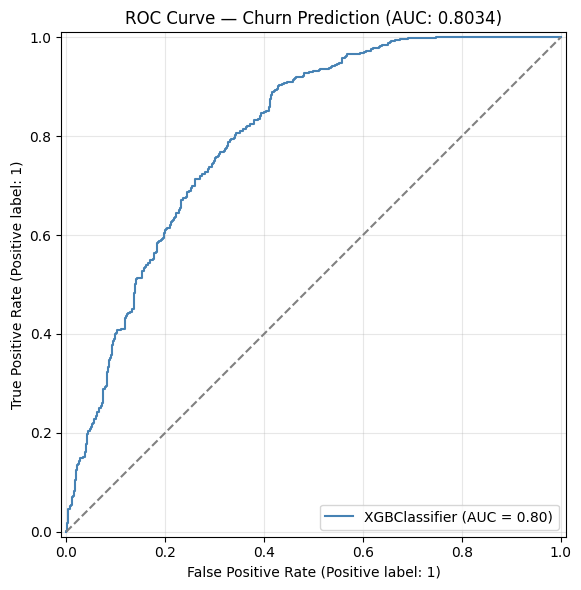

In [119]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, ax=ax, color="steelblue")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title(f"ROC Curve — Churn Prediction (AUC: {auc:.4f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

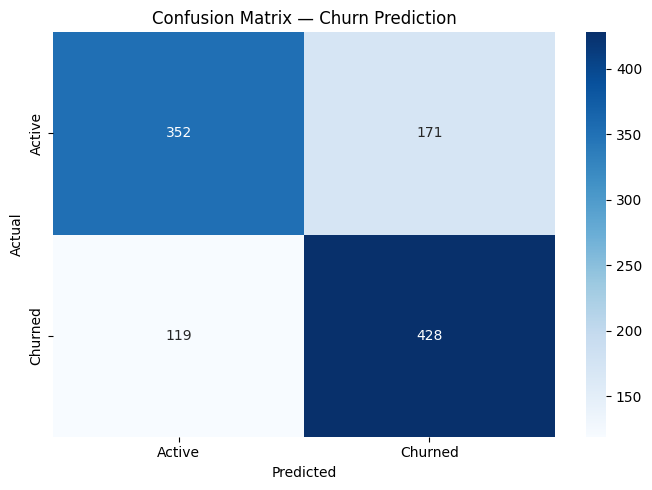

In [120]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.title("Confusion Matrix — Churn Prediction")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [121]:
# SHAP Explainability

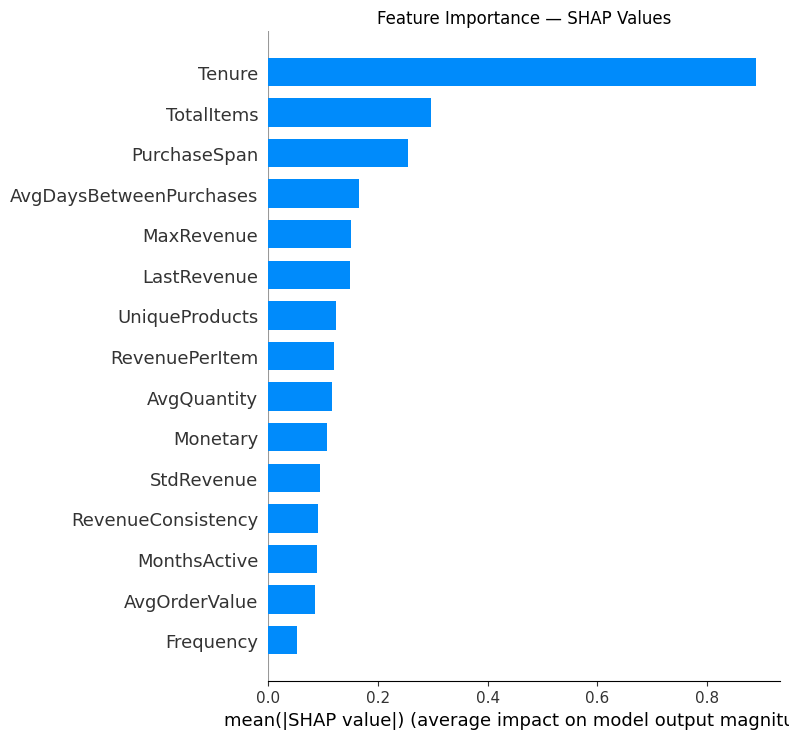

In [122]:
!pip install shap -q

import shap

explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test)

plt.figure(figsize=(20, 10))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance — SHAP Values")
plt.tight_layout()
plt.show()

In [123]:
# Churn Risk Segments

Risk Segments:
Risk_Segment
High Risk      2554
Low Risk       1644
Medium Risk    1152
Name: count, dtype: int64


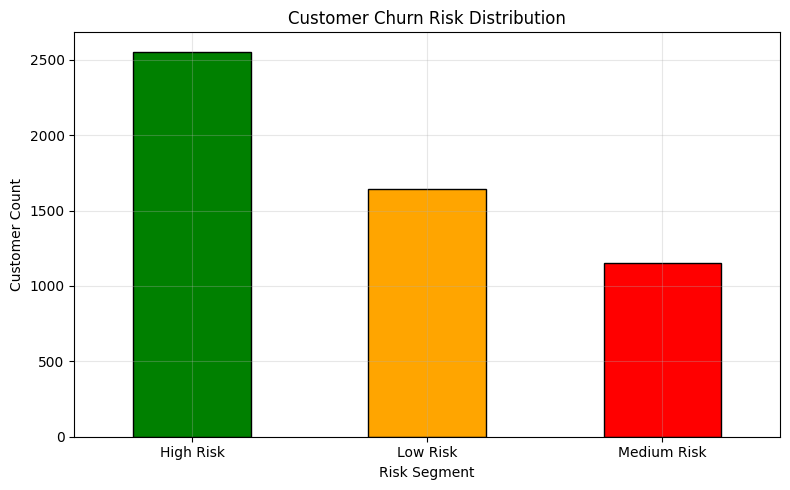

In [124]:
churn_df["Churn_Probability"] = xgb_model.predict_proba(
    churn_df[features]
)[:, 1]

churn_df["Risk_Segment"] = pd.cut(
    churn_df["Churn_Probability"],
    bins   = [0, 0.3, 0.6, 1.0],
    labels = ["Low Risk", "Medium Risk", "High Risk"]
)

print("Risk Segments:")
print(churn_df["Risk_Segment"].value_counts())

plt.figure(figsize=(8, 5))
churn_df["Risk_Segment"].value_counts().plot(
    kind="bar", color=["green", "orange", "red"], edgecolor="black"
)
plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Inventory Optimization

In [125]:
# Prophet forecast use karo — next 30 days ki demand
future_inv = prophet_model.make_future_dataframe(periods=60, freq="D")
future_inv["is_weekend"] = future_inv["ds"].dt.dayofweek.isin([5, 6]).astype(int)
forecast_inv = prophet_model.predict(future_inv)

# Next 30 days
next_30 = forecast_inv.tail(30)[["ds", "yhat"]].copy()
next_30["yhat"] = next_30["yhat"].clip(lower=0)
next_30.columns = ["Date", "Forecasted_Revenue"]

# Safety stock — 20% buffer
next_30["Safety_Stock"]     = next_30["Forecasted_Revenue"] * 0.20
next_30["Reorder_Quantity"] = next_30["Forecasted_Revenue"] + next_30["Safety_Stock"]
next_30["Reorder_Quantity"] = next_30["Reorder_Quantity"].round(2)

print("Inventory Plan — Next 30 Days:")
print(next_30.head(10).to_string(index=False))

Inventory Plan — Next 30 Days:
      Date  Forecasted_Revenue  Safety_Stock  Reorder_Quantity
2011-12-05        39017.251225   7803.450245          46820.70
2011-12-06        42830.581850   8566.116370          51396.70
2011-12-07        37355.289765   7471.057953          44826.35
2011-12-08        46720.063534   9344.012707          56064.08
2011-12-09        31774.293707   6354.858741          38129.15
2011-12-10         5687.018191   1137.403638           6824.42
2011-12-11        22423.076624   4484.615325          26907.69
2011-12-12        32316.225167   6463.245033          38779.47
2011-12-13        35439.199887   7087.839977          42527.04
2011-12-14        29170.368343   5834.073669          35004.44


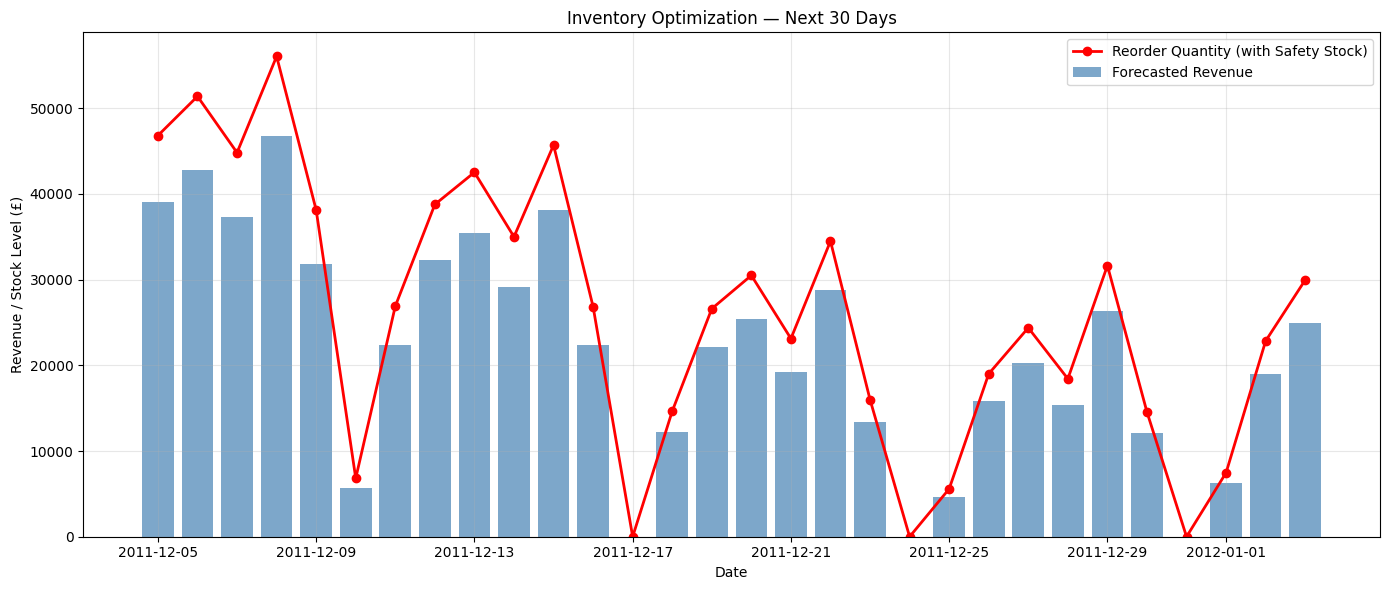

In [126]:
plt.figure(figsize=(14, 6))
plt.bar(next_30["Date"], next_30["Forecasted_Revenue"],
        label="Forecasted Revenue", color="steelblue", alpha=0.7)
plt.plot(next_30["Date"], next_30["Reorder_Quantity"],
         label="Reorder Quantity (with Safety Stock)",
         color="red", linewidth=2, marker="o")
plt.title("Inventory Optimization — Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Revenue / Stock Level (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 MLflow Complete Tracking

In [127]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.4/94

In [128]:
# !pip install --upgrade xgboost

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("RetailPulse_Complete")


with mlflow.start_run(run_name="RetailPulse_All_Models"):

    # Prophet
    mlflow.log_param("prophet_seasonality_mode",      "multiplicative")
    mlflow.log_param("prophet_changepoint_prior",      0.05)
    mlflow.log_param("prophet_holidays",               "GB")
    mlflow.log_metric("prophet_mae",                   prophet_mae)
    mlflow.log_metric("prophet_rmse",                  prophet_rmse)
    mlflow.log_metric("prophet_mape",                  prophet_mape)
    mlflow.log_metric("prophet_normal_days_mae",       prophet_mae_normal)

    # LSTM
    mlflow.log_param("lstm_hidden_size",               64)
    mlflow.log_param("lstm_num_layers",                1)
    mlflow.log_param("lstm_sequence_length",           30)
    mlflow.log_param("lstm_batch_size",                16)
    mlflow.log_param("lstm_epochs",                    500)
    mlflow.log_metric("lstm_mae",                      lstm_mae)
    mlflow.log_metric("lstm_rmse",                     lstm_rmse)
    mlflow.log_metric("lstm_mape",                     lstm_mape)

    # Hybrid
    mlflow.log_param("hybrid_w_prophet",               0.70)
    mlflow.log_param("hybrid_w_lstm",                  0.30)
    mlflow.log_metric("hybrid_mae",                    hybrid_mae)
    mlflow.log_metric("hybrid_rmse",                   hybrid_rmse)
    mlflow.log_metric("hybrid_mape",                   hybrid_mape)

    # Churn
    mlflow.log_param("churn_model",                    "XGBoost")
    mlflow.log_param("churn_features",                 str(features))
    mlflow.log_param("churn_threshold_days",           90)
    mlflow.log_metric("churn_auc_roc",                 auc)
    mlflow.xgboost.log_model(
        xgb_model=xgb_model,
        artifact_path="churn_model"
    )

    print("=" * 50)
    print("  MLflow Tracking Complete ✅")
    print("=" * 50)
    print(f"  Prophet MAE     : {prophet_mae:,.2f}")
    print(f"  LSTM MAE        : {lstm_mae:,.2f}")
    print(f"  Hybrid MAE      : {hybrid_mae:,.2f}")
    print(f"  Churn AUC-ROC   : {auc:.4f}")
    print("=" * 50)

2026/06/25 19:10:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/25 19:10:29 INFO mlflow.store.db.utils: Updating database tables
2026/06/25 19:10:36 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Complete' does not exist. Creating a new experiment.
2026/06/25 19:10:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  MLflow Tracking Complete ✅
  Prophet MAE     : 12,896.68
  LSTM MAE        : 14,771.68
  Hybrid MAE      : 12,780.10
  Churn AUC-ROC   : 0.8034


Evidently AI Drift Detection

   DATA DRIFT REPORT
  Train mean     : £22,659.97
  Test mean      : £42,754.95
  Mean Drift     : 88.68%
  KS Statistic   : 0.5618
  KS p-value     : 0.0000

 Drift Detected — Distribution significantly different
 Recommendation: Retrain model with recent data


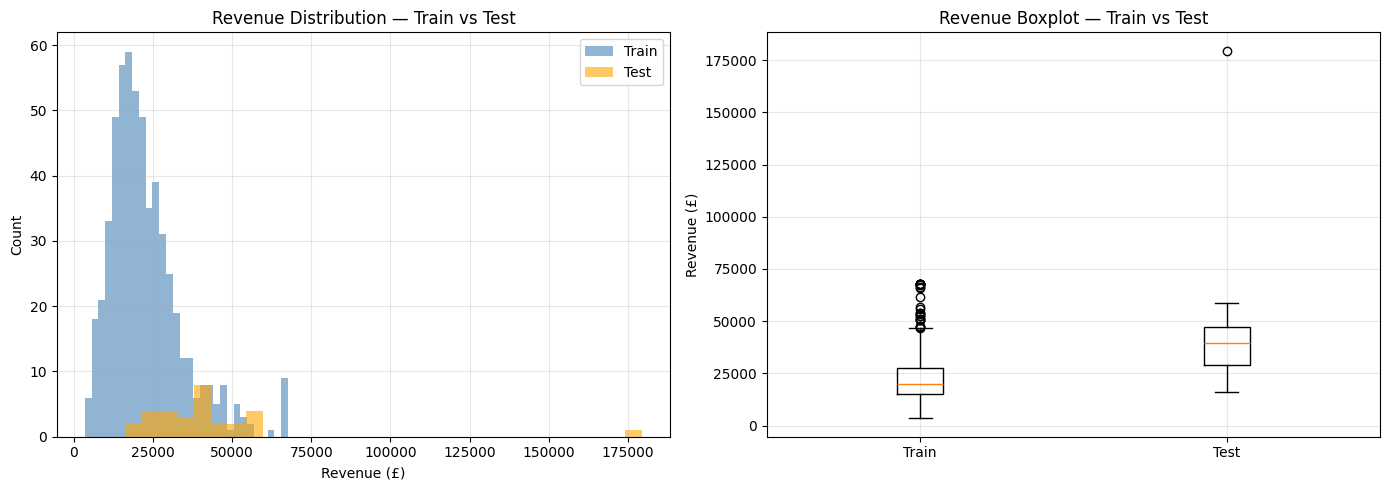

In [ ]:
from scipy import stats
ref_revenue = train_df["y"].values
cur_revenue = test_df["y"].values
ks_stat, ks_pvalue = stats.ks_2samp(ref_revenue, cur_revenue)
ref_mean  = ref_revenue.mean()
cur_mean  = cur_revenue.mean()
drift_pct = abs(cur_mean - ref_mean) / ref_mean * 100

print("=" * 50)
print("   DATA DRIFT REPORT")
print("=" * 50)
print(f"  Train mean     : £{ref_mean:,.2f}")
print(f"  Test mean      : £{cur_mean:,.2f}")
print(f"  Mean Drift     : {drift_pct:.2f}%")
print(f"  KS Statistic   : {ks_stat:.4f}")
print(f"  KS p-value     : {ks_pvalue:.4f}")
print()
if ks_pvalue < 0.05:
    print(" Drift Detected — Distribution significantly different")
    print(" Recommendation: Retrain model with recent data")
else:
    print(" No significant drift detected")
print("=" * 50)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ref_revenue, bins=30, alpha=0.6, color="steelblue", label="Train")
axes[0].hist(cur_revenue, bins=30, alpha=0.6, color="orange", label="Test")
axes[0].set_title("Revenue Distribution — Train vs Test")
axes[0].set_xlabel("Revenue (£)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([ref_revenue, cur_revenue], labels=["Train", "Test"])
axes[1].set_title("Revenue Boxplot — Train vs Test")
axes[1].set_ylabel("Revenue (£)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Retraining Pipeline

In [131]:
def check_and_retrain(ref_data, new_data, threshold=0.15):
    ref_mean  = ref_data["revenue"].mean()
    new_mean  = new_data["revenue"].mean()
    drift_pct = abs(new_mean - ref_mean) / ref_mean

    print(f"Reference mean : £{ref_mean:,.2f}")
    print(f"New data mean  : £{new_mean:,.2f}")
    print(f"Drift          : {drift_pct*100:.2f}%")

    if drift_pct > threshold:
        print("⚠️ Drift detected — Model retraining required!")
        return True
    else:
        print("✅ No significant drift — Model is stable")
        return False

# Reference aur current data banao — train/test se
ref_data = train_df[["y", "is_weekend"]].copy()
ref_data.columns = ["revenue", "is_weekend"]

cur_data = test_df[["y", "is_weekend"]].copy()
cur_data.columns = ["revenue", "is_weekend"]

# Function call karo
needs_retrain = check_and_retrain(ref_data, cur_data)

if needs_retrain:
    print("\nRetraining Prophet model on full data...")

    # Naya Prophet object banao — same as pehle wala
    retrain_model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=1
    )
    retrain_model.add_country_holidays(country_name="GB")
    retrain_model.add_regressor("is_weekend")
    retrain_model.fit(prophet_df)
    print("Retraining complete")

Reference mean : £22,659.97
New data mean  : £42,754.95
Drift          : 88.68%
⚠️ Drift detected — Model retraining required!

Retraining Prophet model on full data...
Retraining complete


MODEL saved

In [ ]:
import pickle
import os

# Models save 
os.makedirs("/content/drive/MyDrive/RetailPulse/models", exist_ok=True)

# Prophet model save
with open("/content/drive/MyDrive/RetailPulse/models/prophet_model.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

# XGBoost model save
with open("/content/drive/MyDrive/RetailPulse/models/xgb_churn_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# LSTM model save
torch.save(lstm_model.state_dict(),
           "/content/drive/MyDrive/RetailPulse/models/lstm_model.pth")

# Scaler save
with open("/content/drive/MyDrive/RetailPulse/models/scaler_lstm.pkl", "wb") as f:
    pickle.dump(scaler_lstm, f)

daily_sales_df.to_csv("/content/drive/MyDrive/RetailPulse/models/daily_sales.csv", index=False)
churn_df.to_csv("/content/drive/MyDrive/RetailPulse/models/churn_data.csv", index=False)
rfm.to_csv("/content/drive/MyDrive/RetailPulse/models/rfm_data.csv", index=False)
next_30.to_csv("/content/drive/MyDrive/RetailPulse/models/inventory_plan.csv", index=False)
comparison_df.to_csv("/content/drive/MyDrive/RetailPulse/models/forecast_comparison.csv", index=False)

print("Location: /content/drive/MyDrive/RetailPulse/models/")

Location: /content/drive/MyDrive/RetailPulse/models/
